# 🐻‍❄️ 투빅스 정규세션 4주차 1교시 Generative AI 코드 과제 🐻‍❄️


이번 과제에서는 VAE 모델과 DCGAN 모델을 직접 구현 및 학습하여 이미지를 생성해보고, 그 결과를 비교해보겠습니다.

- **VAE(Variational AutoEncoder)**: 입력 데이터를 저차원의 잠재 공간(latent space)으로 압축한 뒤, 이 공간의 확률 분포를 기반으로 다시 원본 데이터를 복원 및 생성하도록 하는 모델

- **GAN(Generative Adversarial Network)**: 생성자(Generator)와 판별자(Discriminator)라는 두 개의 네트워크가 서로 경쟁하며 학습하는 모델
  * Generator: Random noise를 입력받아 진짜(Real) 같은 가짜(Fake) 데이터를 생성 (=위조지폐범)
  * Discriminator: 입력받은 데이터가 Real인지 Fake인지 구분 (=경찰)

- **DCGAN (Deep Convolutional GAN)**: 기존 GAN은 단순한 MLP(Multi-Layer Perceptron) 구조인 반면, DCGAN은 이를 Convolutional 구조로 확장하여 이미지의 생성 성능을 향상시킨 모델

### **모듈 임포트 및 디바이스 설정**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### **데이터셋 준비 (MNIST dataset)**

In [2]:
batch_size = 128
epochs = 30

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

## **VAE(Variational AutoEncoder) 모델 정의 및 학습**

* Encoder: 입력 데이터 x를 받아 잠재 공간(Latent Space)의 파라미터를 추출
  * 고차원의 입력데이터를 저차원의 평균과 로그 분산으로 변환
    * 💡 빈칸 채우기 hint) `self.fc1`을 거쳐 특징을 추출한 뒤, 두 개의 서로 다른 선형 레이어를 통해 각각 평균과 로그 분산을 계산

* Latent Space & Reparameterization
  * 잠재 변수 z를 직접 고정된 값으로 뽑는 것이 아니라, encoder가 만든 분포(평균, 로그 분산)에서 샘플링함
  * Reparameterization Trick: backpropagation는 샘플링 연산을 통과할 수 없다는 문제를 해결하기 위해 샘플링 과정을 미분 가능한 형태로 만들기 위한 수식

* Decoder
  * 샘플링된 잠재 변수 z를 다시 원래의 입력 데이터 차원으로 복원

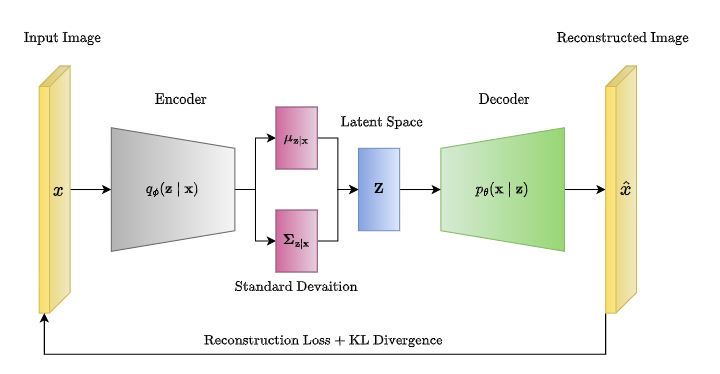

참고 코드: https://github.com/NoviceStone/VAE/blob/master/models.py

In [3]:
class VAE(nn.Module):

    def __init__(self, input_size=784, hidden_size=400, latent_size=20, data_type="binary"):
        super(VAE, self).__init__()

        # Encoder: layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc21 = nn.Linear(hidden_size, latent_size)  # 평균(mu)
        self.fc22 = nn.Linear(hidden_size, latent_size)  # 로그 분산(logvar)

        # Decoder: layers
        self.fc3 = nn.Linear(latent_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, input_size)

        self.data_type = data_type

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        mean = self.fc21(h1) # 🤔 빈칸을 채워주세요
        log_var = self.fc22(h1) # 🤔 빈칸을 채워주세요
        return mean, log_var

    @staticmethod
    def reparameterize(mean, log_var):

        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)

        z = mean + std * eps
        return z

    def decode(self, z):

        h3 = F.relu(self.fc3(z))

        logits = self.fc4(h3)
        probs = torch.sigmoid(logits)

        return probs

    def forward(self, x):

        x = x.view(-1, 784)

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        recon = self.decode(z)

        return recon, mu, logvar

### **VAE loss (ELBO)**
* Reconsturction Loss: 복원된 이미지(`recon_x`)가 원본 이미지(`x`)와 얼마나 다른지 측정
* KL Divergence: 잠재공간의 분포가 표준 정규븐포와 얼마나 다른지 측정

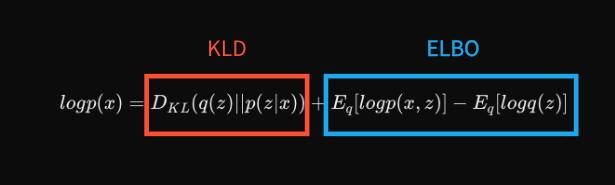


In [4]:
def elbo_loss(x, recon_x, mu, logvar):

    B = x.size(0)

    x = x.view(-1, 784)

    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum') / B # 🤔 빈칸을 채워주세요

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B # 🤔 빈칸을 채워주세요

    total_loss = BCE + KLD # 🤔 빈칸을 채워주세요

    return total_loss

## **🙋 [VAE] Question 1**
VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유를 설명해주세요.



* Latent Space를 z의 가정인 표준정규분포로부터 멀어지지 않도록 하기 위해서이다.

In [5]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(epochs):


    # ========== Train ==========
    vae.train()
    train_loss = 0

    for x,_ in train_loader:

        x = x.to(device)

        recon, mu, logvar = vae(x)

        loss = elbo_loss(x,recon, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dataset)


    # ========== Validation ==========
    vae.eval()
    val_loss = 0

    with torch.no_grad():

        for x,_ in val_loader:

            x = x.to(device)

            recon, mu, logvar = vae(x)

            loss = elbo_loss(x, recon, mu, logvar)

            val_loss += loss.item()

    val_loss /= len(val_dataset)

    print(f"[VAE] Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

[VAE] Epoch 1/30 | Train Loss: 1.3198 | Val Loss: 1.0302
[VAE] Epoch 2/30 | Train Loss: 0.9671 | Val Loss: 0.9252
[VAE] Epoch 3/30 | Train Loss: 0.9060 | Val Loss: 0.8905
[VAE] Epoch 4/30 | Train Loss: 0.8801 | Val Loss: 0.8720
[VAE] Epoch 5/30 | Train Loss: 0.8651 | Val Loss: 0.8621
[VAE] Epoch 6/30 | Train Loss: 0.8552 | Val Loss: 0.8533
[VAE] Epoch 7/30 | Train Loss: 0.8485 | Val Loss: 0.8477
[VAE] Epoch 8/30 | Train Loss: 0.8427 | Val Loss: 0.8434
[VAE] Epoch 9/30 | Train Loss: 0.8376 | Val Loss: 0.8390
[VAE] Epoch 10/30 | Train Loss: 0.8346 | Val Loss: 0.8371
[VAE] Epoch 11/30 | Train Loss: 0.8317 | Val Loss: 0.8349
[VAE] Epoch 12/30 | Train Loss: 0.8289 | Val Loss: 0.8321
[VAE] Epoch 13/30 | Train Loss: 0.8266 | Val Loss: 0.8301
[VAE] Epoch 14/30 | Train Loss: 0.8244 | Val Loss: 0.8285
[VAE] Epoch 15/30 | Train Loss: 0.8224 | Val Loss: 0.8254
[VAE] Epoch 16/30 | Train Loss: 0.8210 | Val Loss: 0.8259
[VAE] Epoch 17/30 | Train Loss: 0.8195 | Val Loss: 0.8252
[VAE] Epoch 18/30 | Tra

**VAE sampling 시각화**

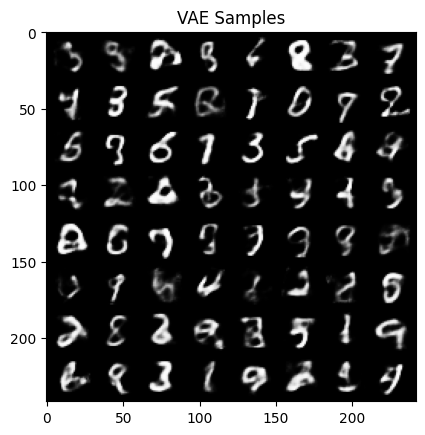

In [6]:
with torch.no_grad():

    z = torch.randn(64,20).to(device)

    samples = vae.decode(z).view(-1,1,28,28)

    grid = make_grid(samples,8)

plt.imshow(grid.permute(1,2,0).cpu())
plt.title("VAE Samples")
plt.show()

## **DCGAN(Deep Convolutional GAN) 모델 정의 및 학습**
- Weight Initialization
  - 모델의 가중치는 평균이 0, 표준편차가 0.02인 정규분포로 초기화
  - 기존 GAN의 학습 불안정성을 줄이기 위해 DCGAN 논문에서 제안한 아이디어

- Generator (생성자)
  - Transposed Convolution: 저차원의 잠재 벡터를 고해상도 이미지로 확장
  - Batch Normalization: 각 layer의 출력을 정규화하여 학습의 안정성을 높이고 gradient vanishing 문제를 해결
  - Activation: 중간 layer에는 ReLU를 통해 빠른 학습을 진행하고, 마지막 layer에는 이미지의 픽셀 값 범위([-1, 1])를 맞추기 위해 Tanh를 사용

- Discriminator (판별자)
  - Strided Convolution: pooling 대신 stride를 사용하여 특징을 추출
  - LeakyReLU: 음수 영역에 작은 양수 기울기를 부여하여 Gradient Vanishing 문제를 해결
  - Activation: 마지막 layer에 sigmoid를 사용하여 real(1)/fake(0) 사이의 확률 값을 출력


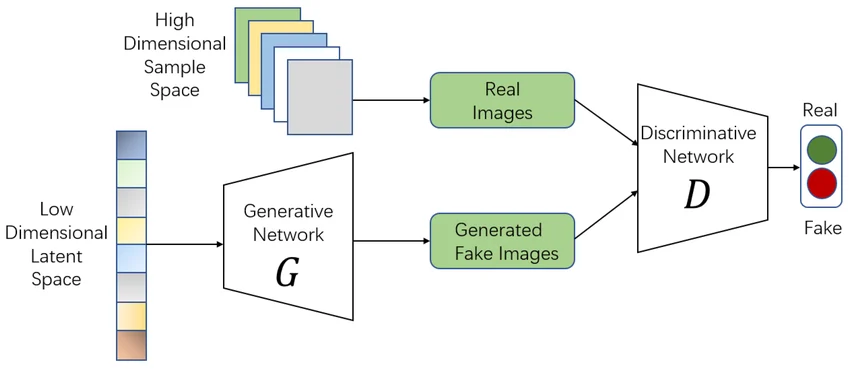


참고 코드: https://github.com/Natsu6767/DCGAN-PyTorch/blob/master/dcgan.py

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [8]:
# weight 초기화 함수

def weights_init(m):

    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [9]:
latent_size = 20

class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.tconv1 = nn.ConvTranspose2d(latent_size,256,7,1,0,bias=False)
        self.bn1 = nn.BatchNorm2d(256)

        self.tconv2 = nn.ConvTranspose2d(256,128,4,2,1,bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.tconv3 = nn.ConvTranspose2d(128,64,4,2,1,bias=False)
        self.bn3 = nn.BatchNorm2d(64)

        self.tconv4 = nn.ConvTranspose2d(64,1,3,1,1,bias=False)

    def forward(self,x):

        x = F.relu(self.bn1(self.tconv1(x)))
        x = F.relu(self.bn2(self.tconv2(x)))
        x = F.relu(self.bn3(self.tconv3(x)))

        x = torch.tanh(self.tconv4(x))

        return x

In [10]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1,out_channels=64,kernel_size=4,stride=2,padding=1,bias=False)

        self.conv2 = nn.Conv2d(64,128,4,2,1,bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128,256,4,2,1,bias=False)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256,1,3,1,0,bias=False)

    def forward(self,x):

        x = F.leaky_relu(self.conv1(x),0.2,True)

        x = F.leaky_relu(self.bn2(self.conv2(x)),0.2,True)

        x = F.leaky_relu(self.bn3(self.conv3(x)),0.2,True)

        x = torch.sigmoid(self.conv4(x))

        return x.view(-1)

In [11]:
G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optG = optim.Adam(G.parameters(),0.0002,betas=(0.5,0.999))
optD = optim.Adam(D.parameters(),0.0002,betas=(0.5,0.999))

In [12]:
for epoch in range(epochs):

    G.train()
    D.train()

    train_lossD = 0
    train_lossG = 0

    for x,_ in train_loader:

        x = x.to(device)

        real = torch.ones(x.size(0)).to(device)
        fake = torch.zeros(x.size(0)).to(device)


        # ========== Train Discriminator ==========

        z = torch.randn(x.size(0),latent_size,1,1).to(device)

        fake_img = G(z)

        loss_real = criterion(D(x), real)
        loss_fake = criterion(D(fake_img.detach()), fake)

        lossD = loss_real + loss_fake

        optD.zero_grad()
        lossD.backward()
        optD.step()


        # ========== Train Generator ==========

        lossG = criterion(D(fake_img), real) # 🤔 빈칸을 채워주세요

        optG.zero_grad()
        lossG.backward()
        optG.step()

        train_lossD += lossD.item()
        train_lossG += lossG.item()

    train_lossD /= len(train_loader)
    train_lossG /= len(train_loader)

    print(f"[DCGAN] Epoch {epoch+1}/{epochs} | Train D Loss {train_lossD:.4f} | Train G Loss {train_lossG:.4f}")

[DCGAN] Epoch 1/30 | Train D Loss 0.7744 | Train G Loss 1.7560
[DCGAN] Epoch 2/30 | Train D Loss 0.9195 | Train G Loss 1.4392
[DCGAN] Epoch 3/30 | Train D Loss 0.9939 | Train G Loss 1.3111
[DCGAN] Epoch 4/30 | Train D Loss 1.0232 | Train G Loss 1.2952
[DCGAN] Epoch 5/30 | Train D Loss 1.0127 | Train G Loss 1.3192
[DCGAN] Epoch 6/30 | Train D Loss 1.0095 | Train G Loss 1.3343
[DCGAN] Epoch 7/30 | Train D Loss 1.0300 | Train G Loss 1.3276
[DCGAN] Epoch 8/30 | Train D Loss 1.0040 | Train G Loss 1.3711
[DCGAN] Epoch 9/30 | Train D Loss 1.0226 | Train G Loss 1.3530
[DCGAN] Epoch 10/30 | Train D Loss 1.0106 | Train G Loss 1.3726
[DCGAN] Epoch 11/30 | Train D Loss 0.9708 | Train G Loss 1.4324
[DCGAN] Epoch 12/30 | Train D Loss 0.9593 | Train G Loss 1.4583
[DCGAN] Epoch 13/30 | Train D Loss 0.9542 | Train G Loss 1.4742
[DCGAN] Epoch 14/30 | Train D Loss 0.9375 | Train G Loss 1.5034
[DCGAN] Epoch 15/30 | Train D Loss 0.9195 | Train G Loss 1.5377
[DCGAN] Epoch 16/30 | Train D Loss 0.9201 | Train

**DCGAN Sampling 시각화**

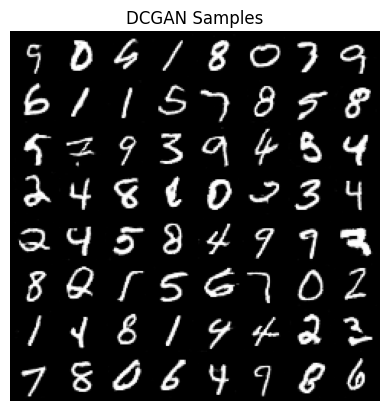

In [13]:
G.eval()

with torch.no_grad():

    z = torch.randn(64,latent_size,1,1).to(device)

    samples = G(z)

grid = make_grid(samples,8,normalize=True)

plt.imshow(grid.permute(1,2,0).cpu())
plt.title("DCGAN Samples")
plt.axis("off")
plt.show()

## **🙋 [GAN] Question 2-1**
VAE와 DCGAN으로 MNIST 이미지를 생성한 결과 VAE는 흐릿한 이미지, DCGAN은 선명한 이미지가 생성된 것을 알 수 있습니다. 그 이유를 VAE와 GAN의 특징과 학습 방식을 포함하여 설명해주세요.

* VAE는 픽셀 차이 기반 Loss를 사용하는데 잠재공간에 대해 정규분포 가정을 하고 있어, 데이터의 세부 특징이 아닌 전체 분포의 평균값에 가까운 출력을 내놓는다. 따라서 여러 위치의 평균적인 값을 예측하여 흐릿한 이미지가 나온다.
* DCGAN의 경우 Generator와 Discriminator가 대립하며 학습하여 Adversarial Loss를 사용한다. Generator가 Discriminator를 속이기 위해 실제 데이터와 유사한 디테일과 특징을 우선적으로 학습하게 된다.

## **🙋 [GAN] Question 2-2**
GAN 학습 과정에서 Generator의 Loss가 증가하는 것이 반드시 모델 성능 악화를 의미하지 않는 이유는 무엇인지 설명해주세요.

* Generator의 Loss는 그 자체의 절대적인 값보다는 Discriminator(판별자)와의 상대적인 관계 내에서 해석되어야 한다.Discriminator가 똑똑해질수록 Generator가 속이기 어려워져 Generator의 Loss는 오르지만, 실제 이미지 품질은 개선될 수 있다.

수고하셨습니다 ☺️